In [1]:
import rebound
import matplotlib.pyplot as plt
import numpy as np
import os

np.random.seed(777)

# Setup
sim = rebound.Simulation()
sim.integrator = "mercurius"
sim.units = ("yr", "AU", "Msun")
date = "JD2460502.000185" 
h = rebound.hash

# Delete discard file each time we restart simulation
discard_file_name = "outputs/orbital_integration/discards.txt"
try:
    os.remove(discard_file_name)
except:
    pass

In [2]:
# Add sun
sim.add("Sun", date = date, hash = 0)
print("Mass of the Sun = {}".format(sim.particles[h(0)].m))
print("GM = {}".format(sim.G * sim.particles[h(0)].m))
sim.particles[h(0)].r = 0.0046524726 # Sun radius AU

# Add other planets: Venus, Earth, Mars, Jupiter, Saturn, Uranus, Neptune
sim.add("Venus", hash = 1)
sim.add("Earth", hash = 2)
sim.add("Mars", hash = 3)
sim.add("Jupiter", hash = 4)
sim.add("Saturn", hash = 5)
sim.add("Uranus", hash = 6)
sim.add("Neptune", hash = 7)

# Planet radii in AU
# https://science.nasa.gov/resource/solar-system-sizes/
sim.particles[h(1)].r = 4.044933e-5
sim.particles[h(2)].r = 4.259013e-5
sim.particles[h(3)].r = 2.265593e-5
sim.particles[h(4)].r = 0.0004673296
sim.particles[h(5)].r = 0.00038926024
sim.particles[h(6)].r = 0.00016953217
sim.particles[h(7)].r = 0.00016458358

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Mass of the Sun = 0.9999999999950272
GM = 39.47692642117669
Searching NASA Horizons for 'Venus'... 
Found: Venus Barycenter (299) (chosen from query 'Venus')
Searching NASA Horizons for 'Earth'... 
Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
Searching NASA Horizons for 'Mars'... 
Found: Mars Barycenter (4) (chosen from query 'Mars')
Searching NASA Horizons for 'Jupiter'... 
Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Searching NASA Horizons for 'Saturn'... 
Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Searching NASA Horizons for 'Uranus'... 
Found: Uranus Barycenter (7) (chosen from query 'Uranus')
Searching NASA Horizons for 'Neptune'... 
Found: Neptune Barycenter (8) (chosen from query 'Neptune')


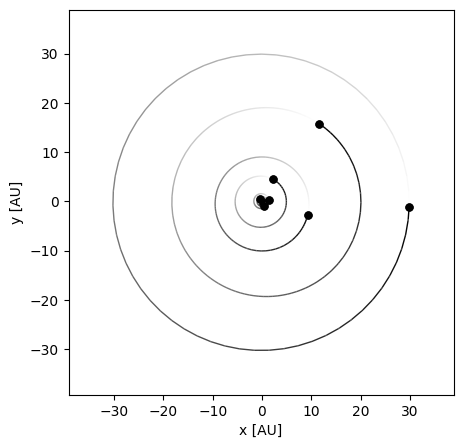

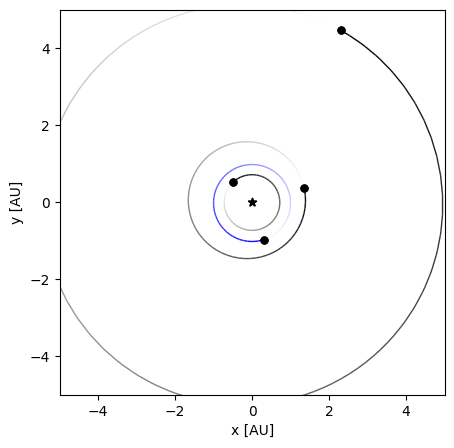

In [3]:
# Show Solar System
rebound.OrbitPlot(sim, unitlabel = "[AU]")
plt.show()

# Inner Solar System with Earth as blue
rebound.OrbitPlot(sim, unitlabel = "[AU]", xlim = [-5, 5], ylim = [-5, 5],
                  color = ["black", "blue", "black", "black", "black", "black"])
plt.show()

In [4]:
sim.status()

---------------------------------
REBOUND version:     	4.4.2
REBOUND built on:    	Jul 15 2024 18:47:33
Number of particles: 	8
Selected integrator: 	mercurius
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x23ce69749d0, m=0.9999999999950272 x=-0.006900291398600675 y=-0.00410978598537011 z=0.00019727501387255614 vx=0.0022817576898216925 vy=-0.0019772087385490117 vz=-3.2562943462252995e-05>
<rebound.particle.Particle object at 0x23ce69777d0, m=2.447838287784771e-06 x=-0.48913377022776805 y=0.5273037168288156 z=0.03532080106016375 vx=-5.4945344570734935 vy=-5.005970314828793 vz=0.24841523147915542>
<rebound.particle.Particle object at 0x23ce69749d0, m=3.0404326489511185e-06 x=0.3137256265274035 y=-0.9688466250557449 z=0.0002496794078114635 vx=5.863314883021352 vy=1.9561385000242826 vz=-0.00017520916393249785>
<rebound.particle.Particle object at 0x23ce69777d0, m=3.2271560828978514e-07 x=

In [5]:
N_pl = 8 # Total number of bodies
sim.N_active = N_pl

In [6]:
# Add asteroid
sim.add(a = 3.245761552052847, e = 0.6141866747698732,
        inc = np.radians(9.98211483642601),
        Omega = np.radians(148.00823478480334),
        omega = np.radians(142.38377885236548), 
        M = np.radians(359.16509165962776), 
        hash = 100)
sim.particles[h(100)].r = 6.68459e-9 # Assume radius is 1km

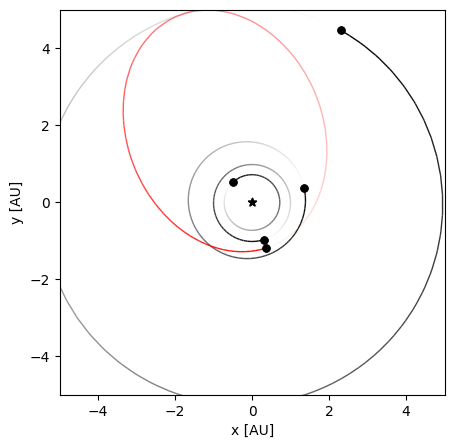

In [7]:
# Make planets different color from asteroid
rebound.OrbitPlot(sim, unitlabel = "[AU]", 
                  xlim = [-5, 5], ylim = [-5, 5], 
                  color = (N_pl - 1) * ["black"] + ["red"])

In [8]:
# Add clones of original asteroid with small offsets
N_tp = 15 # Number of test particles

# Elements of first asteroid particle
x = sim.particles[h(100)].x
y = sim.particles[h(100)].y
z = sim.particles[h(100)].z
vx = sim.particles[h(100)].vx
vy = sim.particles[h(100)].vy
vz = sim.particles[h(100)].vz

# Add particles
# Use uncertainties from Monte Carlo
for i in range(1, N_tp):
    hash_value = 100 + i
    sim.add(x = np.random.normal(x, 4.8733701604141086e-05), 
            y = np.random.normal(y, 5.2951495420704535e-06),
            z = np.random.normal(z, 5.9495960153409435e-05),
            vx = np.random.normal(vx, 4.101200968610788e-05),
            vy = np.random.normal(vy, 5.893448001999183e-05), 
            vz = np.random.normal(vz, 1.2155350348219567e-05),
            r = 6.68459e-9,
            hash = hash_value)

In [9]:
# Check that each particle has a unique hash
for p in sim.particles:
    print(p.hash.value)

0
1
2
3
4
5
6
7
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114


In [10]:
# Check that we have correct number of particles
print(sim.N)

23


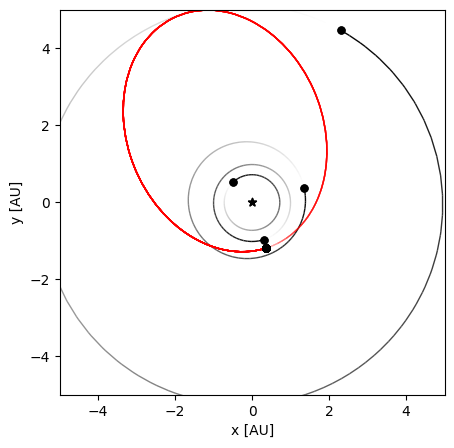

In [11]:
rebound.OrbitPlot(sim, unitlabel = "[AU]", 
                  xlim = [-5, 5], ylim = [-5, 5], 
                  color = (N_pl - 1) * ["black"] + N_tp * ["red"])

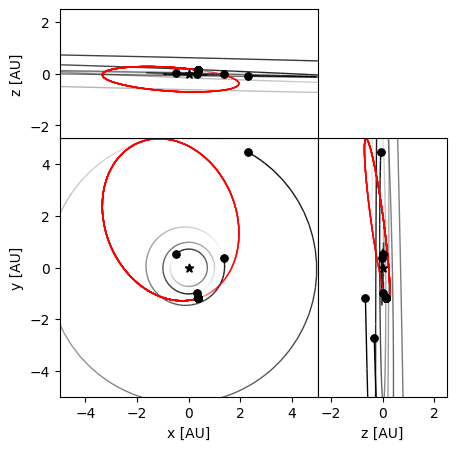

In [12]:
# 3d plot
rebound.OrbitPlotSet(sim, unitlabel = "[AU]", 
                     xlim = [-5, 5], ylim = [-5, 5], 
                     color = (N_pl - 1) * ["black"] + N_tp * ["red"])

In [13]:
# Set up simulation parameters
sim.exit_max_distance = 1000 # 1000 AU from sun=ejected from system
sim.collision = "direct"
discard_file_name = "outputs/orbital_integration/discards.txt"

def collision_discard_log(sim_pointer, collision, 
                          discard_file_name = discard_file_name):
    sim = sim_pointer.contents
    id_p1 = sim.particles[collision.p1].hash.value
    id_p2 = sim.particles[collision.p2].hash.value

    discard_file = open(discard_file_name, "a")

    if id_p1 > id_p2:
        print("Particle {0} collided with {1} at {2} yrs".format(id_p1, id_p2, sim.t))
        print("Particle {0} collided with {1} at {2} yrs".format(id_p1, id_p2, sim.t), file = discard_file)
        print("Removing particle {0}".format(id_p1))
        ToRemove = 1
    else:
        print("Particle {0} collided with {1} at {2} yrs".format(id_p2, id_p1, sim.t))
        print("Particle {0} collided with {1} at {2} yrs".format(id_p2, id_p1, sim.t), file = discard_file)
        print("Removing particle {0}".format(id_p2))
        ToRemove = 2
    
    discard_file.close()
    return ToRemove

sim.collision_resolve = collision_discard_log

sim.move_to_com() # Move to center of momentum frame
tend = 50e6 # Time to stop integration in years
tout = 1000 # Output every 1000 years
sim.dt = sim.particles[h(1)].P / 25 # Time step

# Save information to simulation archive
archive = "outputs/orbital_integration/archive.bin"
sim.save_to_file(archive, interval = tout, delete_file = True)
times = np.arange(0, tend, tout)
Nsteps = len(times)

In [14]:
# Main loop of simulation
for i in range(Nsteps):

    try:
        # Try to do an integration step to the next output timestep
        sim.integrate(times[i], exact_finish_time = 0)

    except rebound.Escape as error:
        # Except if particle goes too far away
        for j in range(sim.N):
            p = sim.particles[j]
            d2 = p.x * p.x + p.y * p.y + p.z * p.z # Squared distance to sun
            if d2 > (sim.exit_max_distance ** 2):
                index = j
        
        pid = sim.particles[index].hash.value
        print("Particle {0:2d} was too far from the Sun at {1:12.65e} yrs".format(pid, sim.t))
        discard_file = open(discard_file_name, "a")
        print("Particle {0:2d} was too far from the Sun at {1:12.65e} yrs".format(pid, sim.t), file = discard_file)
        discard_file.close()

        sim.remove(index = index)


    print("Time {0:6.3f} Myr-- Fraction Done {1:5.4f} -- # of Clones {2}".format(sim.t/1e6, sim.t/tend, sim.N - N_pl))

    # End integration if all particles have been discarded
    if sim.N <= N_pl:
        print("No more test particles, ending simulation")
        break

Time  0.000 Myr-- Fraction Done 0.0000 -- # of Clones 15
Time  0.001 Myr-- Fraction Done 0.0000 -- # of Clones 15
Time  0.002 Myr-- Fraction Done 0.0000 -- # of Clones 15
Time  0.003 Myr-- Fraction Done 0.0001 -- # of Clones 15
Time  0.004 Myr-- Fraction Done 0.0001 -- # of Clones 15
Time  0.005 Myr-- Fraction Done 0.0001 -- # of Clones 15
Time  0.006 Myr-- Fraction Done 0.0001 -- # of Clones 15
Time  0.007 Myr-- Fraction Done 0.0001 -- # of Clones 15
Time  0.008 Myr-- Fraction Done 0.0002 -- # of Clones 15
Time  0.009 Myr-- Fraction Done 0.0002 -- # of Clones 15
Time  0.010 Myr-- Fraction Done 0.0002 -- # of Clones 15
Time  0.011 Myr-- Fraction Done 0.0002 -- # of Clones 15
Time  0.012 Myr-- Fraction Done 0.0002 -- # of Clones 15
Time  0.013 Myr-- Fraction Done 0.0003 -- # of Clones 15
Time  0.014 Myr-- Fraction Done 0.0003 -- # of Clones 15
Time  0.015 Myr-- Fraction Done 0.0003 -- # of Clones 15
Time  0.016 Myr-- Fraction Done 0.0003 -- # of Clones 15
Time  0.017 Myr-- Fraction Done

KeyboardInterrupt: 